# A7 Feature EDA — Full Feature-Set EDA

Comprehensive exploratory analysis of the model's full feature set (127 columns),
motivated by the raw-fingerprint feature redesign's finding that raw fingerprint
components (`away_style_pace_score`, `home_style_pace_score`) outrank `elo_diff` in
CatBoost feature importance, with mixed accuracy effects (`total_mae` improved,
`win_acc` worsened). Both A7 feature flags (`style_matchup.enabled`,
`style_matchup.raw_features_enabled`) are temporarily enabled here as a **local,
in-memory config override for this analysis only** — the committed
`configs/config.yaml` defaults stay `false` (see `docs/a7_phase_log.md`'s Feature
EDA section).

See `docs/feature_eda_insights.md` for the concise, bulleted write-up of findings.
This notebook is the full exploratory trail behind that doc.

In [1]:
import sys
sys.path.append('..')

import os
os.chdir('..')  # repo root -- config-relative paths (data/raw/*, outputs/*) assume this cwd, matching train_model.py/precompute scripts

import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', None)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports successful!")

Imports successful!


## Section 1: Build the full feature set (local config override)

`style_matchup.enabled` and `style_matchup.raw_features_enabled` both default to
`false` in `configs/config.yaml` (neither was adopted — see the KNN-Score
Integration Test / Raw-Fingerprint Feature Redesign sections). We need
both `true` to analyze every feature currently implemented, not just the 107
default-enabled ones. Rather than editing the committed yaml, we load the config
normally and then override just these two fields in memory (pydantic model is
`frozen=True`, so `model_copy(update=...)` is the clean way to do this), and
monkeypatch the `load_config` reference `feature_builder` already imported so
`_add_style_matchup_features`/`_add_style_fingerprint_features` see the override.

In [2]:
from src.utils.config_loader import load_config
from src.data_processing.data_loader import NBADataLoader
from src.feature_engineering.feature_builder import FeatureBuilder
import src.feature_engineering.feature_builder as fb_mod

cfg = load_config()
print("Committed defaults -- enabled:", cfg.style_matchup.enabled,
      "| raw_features_enabled:", cfg.style_matchup.raw_features_enabled)

# Local, in-memory override for THIS analysis only -- config.yaml is not touched.
cfg_override = cfg.model_copy(update={
    "style_matchup": cfg.style_matchup.model_copy(update={
        "enabled": True,
        "raw_features_enabled": True,
    })
})
fb_mod.load_config = lambda *a, **k: cfg_override
print("Override -- enabled:", cfg_override.style_matchup.enabled,
      "| raw_features_enabled:", cfg_override.style_matchup.raw_features_enabled)

Committed defaults -- enabled: False | raw_features_enabled: False
Override -- enabled: True | raw_features_enabled: True


In [3]:
# Load the full available game history (context start -> test end), same range
# train_model.py/elo use for full-history context -- gives every rolling/H2H/era
# feature its deepest possible lookback window for this analysis.
loader = NBADataLoader(db_path=cfg.data_paths.raw_db)
games = loader.load_games(
    start_date=cfg.datasets_loading.data_start_date,
    end_date=cfg.datasets_loading.test_end_date,
    allowed_season_types=cfg.datasets_loading.context_season_types or cfg.datasets_loading.allowed_season_types,
)
loader.close()
print(f"{len(games):,} games loaded, {games['GAME_DATE'].min().date()} .. {games['GAME_DATE'].max().date()}")
games['SEASON_TYPE'].value_counts()

INFO:src.data_processing.data_loader:Loaded 12,717 games (2016-10-25 – 2026-04-12)


12,717 games loaded, 2016-10-25 .. 2026-04-12


SEASON_TYPE
Regular Season    11969
Playoffs            748
Name: count, dtype: int64

In [4]:
fb = FeatureBuilder(
    rolling_windows=cfg.features.rolling_windows,
    h2h_margin_window=cfg.features.h2h_margin_window,
    h2h_win_rate_window=cfg.features.h2h_win_rate_window,
)
df = fb.create_all_features(games)
feature_cols = fb.get_feature_names(df)
label_cols = ['PTS_home', 'PTS_away', 'POINT_DIFF', 'TOTAL_POINTS', 'HOME_TEAM_WINS']

print(f"{len(feature_cols)} feature columns, {len(df):,} games")
df['season_year'] = df['GAME_DATE'].dt.year
df.shape

INFO:src.data_processing.data_loader:Loaded 12,717 games (2016-10-25 – 2026-04-12)


INFO:src.feature_engineering.feature_builder:Features built: 127 cols, 12,717 games (12717 with NaN — kept, CatBoost handles natively)


127 feature columns, 12,717 games


(12717, 149)

**Note on scope:** rows before `train_start_date` (2018-10-16) are context-only —
loaded so rolling/H2H/Elo features have history to draw on, never used as actual
training samples in `train_model.py`. We keep them in this EDA (useful for the
era-drift analysis below) but call out the modeling population's actual date range
where it matters.

Feature families, mapped to `feature_builder.py`'s `_add_*` methods:
- **Basic**: `season_progress`
- **Rolling per-team** (`_add_rolling_features`): win_pct / diff_avg / fg_pct / ft_pct x L5/L10/L20
- **Rest/schedule** (`_add_rest_features`): rest_days, back_to_back, games_in_4_nights
- **Style** (`_add_style_features`): off_eff / def_eff / 3pt_rate x L5/L10/L20
- **Opponent quality** (`_add_opponent_quality_features`): opp_off/def_quality x L5/L10/L20
- **Home advantage** (`_add_home_advantage_features`): venue_delta x L5/L10/L20
- **Matchup differentials** (`_add_matchup_features`): off_vs_def, 3pt_advantage, form/strength differential x L5/L10/L20
- **H2H** (`_add_h2h_features`): h2h_home_margin_L3, h2h_home_win_rate_L5, h2h_win_pct_3yr, h2h_avg_diff, h2h_home/away_win_pct
- **Travel** (`_add_travel_features`): travel_miles, tz_shift, travel_miles_7d/14d
- **Elo** (`_add_elo_features`): home/away_team_elo, elo_diff
- **Injury** (`_add_injury_features`): n_out, n_questionable, team_deficit, team_deficit_diff, has_injury_data
- **A7 KNN-Score Integration Test (KNN lookup)** (`_add_style_matchup_features`): style_matchup_score, style_matchup_confidence
- **A7 Raw-Fingerprint Feature Redesign (raw fingerprint + diff)** (`_add_style_fingerprint_features`): home/away_style_{6 metrics} + style_{metric}_diff

In [5]:
FAMILIES = {
    'basic': ['season_progress'],
    'rolling_per_team': [c for c in feature_cols if any(c.startswith(p) for p in ('home_team_win_pct','away_team_win_pct','home_team_diff_avg','away_team_diff_avg','home_team_fg_pct','away_team_fg_pct','home_team_ft_pct','away_team_ft_pct'))],
    'rest_schedule': [c for c in feature_cols if 'rest_days' in c or 'back_to_back' in c or 'games_in_4_nights' in c],
    'style_rolling': [c for c in feature_cols if any(c.startswith(p) for p in ('home_team_off_eff','away_team_off_eff','home_team_def_eff','away_team_def_eff','home_team_3pt_rate','away_team_3pt_rate'))],
    'opp_quality': [c for c in feature_cols if 'opp_def_quality' in c or 'opp_off_quality' in c],
    'venue_delta': [c for c in feature_cols if 'venue_delta' in c],
    'matchup_diff': [c for c in feature_cols if any(c.startswith(p) for p in ('home_off_vs_away_def','away_off_vs_home_def','home_3pt_advantage','form_differential','strength_differential'))],
    'h2h': [c for c in feature_cols if c.startswith('h2h_')],
    'travel': [c for c in feature_cols if 'travel_miles' in c or 'tz_shift' in c],
    'elo': [c for c in feature_cols if 'elo' in c],
    'injury': [c for c in feature_cols if any(c.startswith(p) for p in ('home_team_n_out','away_team_n_out','home_team_n_questionable','away_team_n_questionable','home_team_team_deficit','away_team_team_deficit')) or c in ('team_deficit_diff','has_injury_data')],
    'a7_knn_lookup': [c for c in feature_cols if c in ('style_matchup_score','style_matchup_confidence')],
    'a7_raw_fingerprint': [c for c in feature_cols if (c.startswith('home_style_') or c.startswith('away_style_') or c.startswith('style_')) and c not in ('style_matchup_score', 'style_matchup_confidence')],
}

covered = set().union(*FAMILIES.values())
uncovered = [c for c in feature_cols if c not in covered]
print("Uncovered columns (should be empty):", uncovered)
for fam, cols in FAMILIES.items():
    print(f"  {fam:22s} {len(cols):3d} cols")
print(f"  {'TOTAL':22s} {sum(len(v) for v in FAMILIES.values()):3d} (of {len(feature_cols)} feature cols)")

Uncovered columns (should be empty): []
  basic                    1 cols
  rolling_per_team        24 cols
  rest_schedule            6 cols
  style_rolling           18 cols
  opp_quality             12 cols
  venue_delta              6 cols
  matchup_diff            15 cols
  h2h                      6 cols
  travel                   8 cols
  elo                      3 cols
  injury                   8 cols
  a7_knn_lookup            2 cols
  a7_raw_fingerprint      18 cols
  TOTAL                  127 (of 127 feature cols)


## Section 2: Distributions by feature family

Summary stats + histograms for a representative member of each family (all L5/L10/L20
variants of one stat overlaid where relevant), flagging anything skewed, bimodal,
zero-inflated, or otherwise unusual.

In [6]:
df[feature_cols].skew().sort_values(key=abs, ascending=False).head(20).to_frame('skewness')

,skewness
away_team_n_questionable,45.924525
home_team_n_questionable,29.988489
away_team_games_in_4_nights,22.050672
home_team_games_in_4_nights,20.518325
style_matchup_confidence,-15.603218
home_team_rest_days,6.626870
away_team_rest_days,6.601548
home_team_back_to_back,3.306558
home_team_team_deficit,2.764482
away_team_team_deficit,2.700137


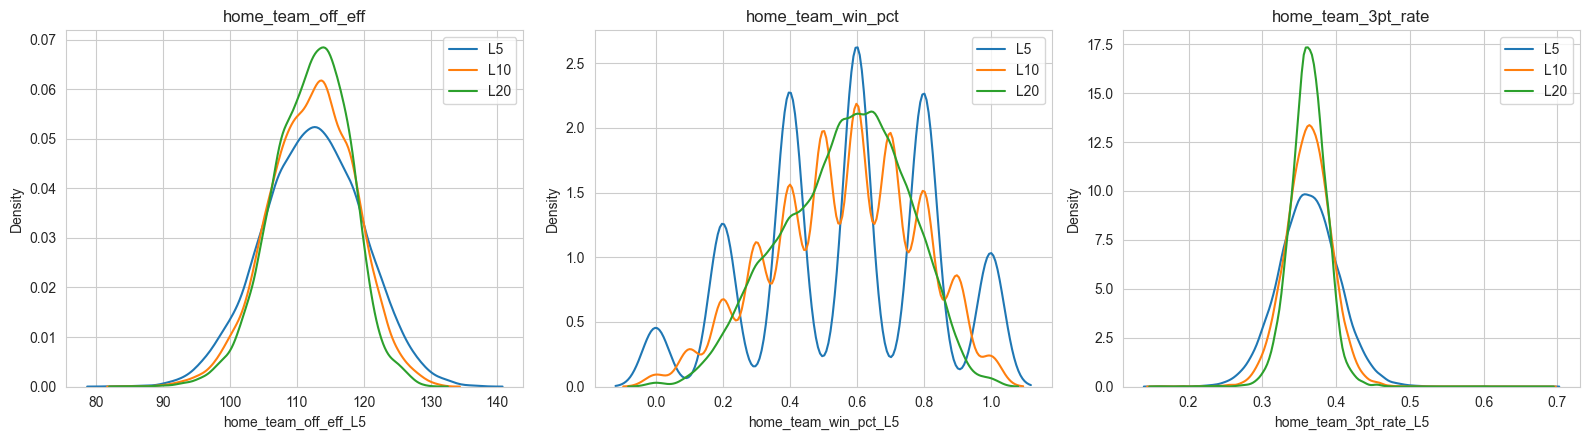

In [7]:
# Rolling per-team + style-rolling: L5/L10/L20 overlay for one representative stat each
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, stat in zip(axes, ['home_team_off_eff', 'home_team_win_pct', 'home_team_3pt_rate']):
    for w in cfg.features.rolling_windows:
        col = f'{stat}_L{w}'
        if col in df.columns:
            sns.kdeplot(df[col].dropna(), ax=ax, label=f'L{w}')
    ax.set_title(stat)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# A7 style-fingerprint metrics (raw-fingerprint feature redesign components) -- all 6, home side
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = ['pace_score', 'three_pt_reliance', 'paint_activity', 'defensive_rating', 'assist_rate', 'offensive_rating']
for ax, m in zip(axes.flat, metrics):
    sns.histplot(df[f'home_style_{m}'].dropna(), ax=ax, kde=True, bins=40)
    ax.set_title(f'home_style_{m}')
plt.tight_layout()
plt.show()

In [ ]:
# A7 KNN-lookup score + confidence (KNN-score integration test)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df['style_matchup_score'].dropna(), ax=axes[0], kde=True, bins=40)
axes[0].set_title('style_matchup_score')
sns.histplot(df['style_matchup_confidence'].dropna(), ax=axes[1], bins=40)
axes[1].set_title('style_matchup_confidence')
plt.tight_layout()
plt.show()

mode_share = df['style_matchup_confidence'].value_counts(normalize=True).iloc[0]
print(f"Share of games at the single most common confidence value: {mode_share:.1%}")
print(df['style_matchup_confidence'].describe())

**Finding — `style_matchup_confidence` is nearly constant.** 99.3% of games land on
the *exact same* value (~0.9878 — the full-confidence ceiling from
`full_confidence_sample=82`). With the corpus this deep (12.7k+ games of history),
almost every KNN search hits full confidence, so the column carries almost no
distinguishing information across games. This is fully consistent with the
KNN-score integration test's finding that `style_matchup_confidence` got **zero**
CatBoost importance — it isn't that the model ignored a useful signal, the column
itself is very close to a constant.

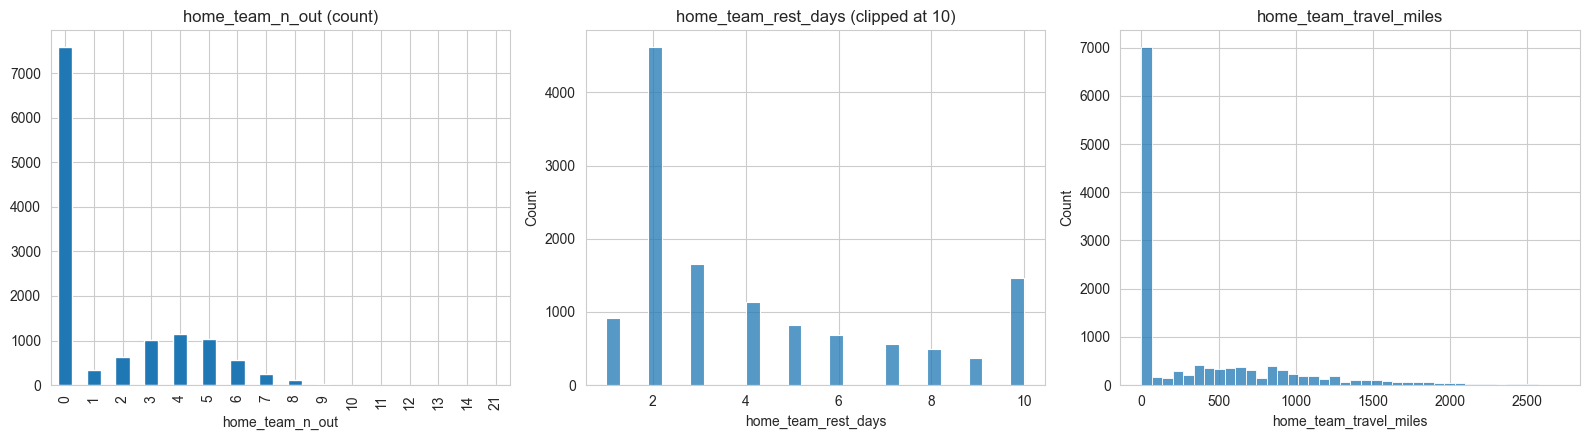

home_team_travel_miles == 0 (no travel, e.g. home stand): 54.9%
home_team_n_out == 0: 59.6%
n_out outlier row(s) (>15):


,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,home_team_n_out
6677,0022100433,2021-12-17,1610612753,1610612748,21


In [10]:
# Injury / rest / travel: count and zero-inflation checks
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
df['home_team_n_out'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('home_team_n_out (count)')
sns.histplot(df['home_team_rest_days'].clip(upper=10), ax=axes[1], bins=30)
axes[1].set_title('home_team_rest_days (clipped at 10)')
sns.histplot(df['home_team_travel_miles'], ax=axes[2], bins=40)
axes[2].set_title('home_team_travel_miles')
plt.tight_layout()
plt.show()

print(f"home_team_travel_miles == 0 (no travel, e.g. home stand): {(df['home_team_travel_miles']==0).mean():.1%}")
print(f"home_team_n_out == 0: {(df['home_team_n_out']==0).mean():.1%}")
outlier = df[df['home_team_n_out'] > 15][['GAME_ID','GAME_DATE','HOME_TEAM_ID','AWAY_TEAM_ID','home_team_n_out']]
print("n_out outlier row(s) (>15):")
outlier

**Finding — `home_team_n_out` outlier is real, not a data bug.** The single row
with `n_out=21` is game `0022100433`, 2021-12-17 — during the December 2021
COVID-19 health-and-safety-protocol wave that forced widespread postponements
league-wide. A legitimate extreme value, not worth capping/removing.

**Zero-inflation, expected:** ~55% of `home_team_travel_miles` rows are exactly
zero (home stands / no travel since the last game) — a real feature of NBA
scheduling, not missing data. `n_questionable` and `games_in_4_nights` are heavily
right-skewed count/binary features for the same reason (most games: no
questionable players, no condensed 3-in-4 stretch).

## Section 3: Missingness

NaN rate per feature, and whether gaps cluster in an interpretable way (known
era-based coverage gaps: pre-2021-22 injury-report era, early-season/early-history
rolling-window warmup).

In [11]:
nan_rate = df[feature_cols].isna().mean().sort_values(ascending=False)
nan_rate[nan_rate > 0].to_frame('nan_rate')

,nan_rate
h2h_win_pct_3yr,0.997169
h2h_home_win_pct,0.068412
h2h_away_win_pct,0.038924
h2h_home_margin_L3,0.034206
h2h_home_win_rate_L5,0.034206
h2h_avg_diff,0.034206
style_matchup_confidence,0.006212
style_matchup_score,0.006212
style_offensive_rating_diff,0.006212
style_three_pt_reliance_diff,0.006212


**`h2h_win_pct_3yr` — 99.7% NaN is a real bug, not a coverage gap.** Traced to
`FeatureBuilder._compute_h2h_3year_win_pct`: inside the per-matchup-key loop, it
builds `matchup_sorted = matchup_games.sort_values('GAME_DATE').reset_index(drop=True)`
(a fresh 0..n-1 index) but then returns
`pd.Series(result, index=matchup_sorted.index).reindex(orig_index)` — `orig_index`
is the *original*, non-contiguous index from the full games dataframe (e.g.
`[100, 489, 659, ...]`), not the 0..n-1 range the result values are actually
indexed by. The `.reindex()` call looks up label `100` in an index that only has
labels `0..n-1`, so it comes back NaN for almost every row — confirmed by direct
reproduction below and by only 36 of 12,717 rows surviving (coincidental overlaps
between small original-index values and the small per-matchup-group range).
Not in scope to fix here (`feature_builder.py` is off-limits this round — see
`docs/feature_eda_insights.md`), but this explains why the correlation table in
Section 5 shows implausibly strong correlations for this column (computed on ~36
essentially-random surviving rows) — **treat any `h2h_win_pct_3yr` correlation
number as noise, not signal.**

In [12]:
# Reproduce the h2h_win_pct_3yr bug directly, isolated from the full pipeline
sample = games[games['GAME_DATE'] < '2019-01-01'].sort_values('GAME_DATE').reset_index(drop=True)
sample['matchup_key'] = sample.apply(lambda r: '_'.join(sorted([str(r['HOME_TEAM_ID']), str(r['AWAY_TEAM_ID'])])), axis=1)
key = sample['matchup_key'].value_counts().index[0]
group_df = sample[sample['matchup_key'] == key]
print("Original (non-contiguous) index of one matchup group:", list(group_df.index)[:8])

matchup_sorted = group_df.sort_values('GAME_DATE').reset_index(drop=True)
print("Index after reset_index(drop=True) inside the method:", list(matchup_sorted.index)[:8])

# This mirrors the method's actual bug: values are indexed 0..n-1, then reindexed
# against the ORIGINAL large index labels -> mismatch -> NaN almost everywhere.
buggy = pd.Series(range(len(matchup_sorted)), index=matchup_sorted.index).reindex(group_df.index)
print("Result after the buggy reindex (all NaN except lucky small-index overlaps):")
print(buggy.values[:8])

Original (non-contiguous) index of one matchup group: [167, 791, 844, 1146, 1231, 1238, 1246, 1258]
Index after reset_index(drop=True) inside the method: [0, 1, 2, 3, 4, 5, 6, 7]
Result after the buggy reindex (all NaN except lucky small-index overlaps):
[nan nan nan nan nan nan nan nan]


In [13]:
# Era-based coverage: has_injury_data / team_deficit by year (pdf_era_start = 2021-10-01)
era_cov = df.groupby('season_year').agg(
    has_injury_data=('has_injury_data', 'mean'),
    team_deficit_nonzero=('home_team_team_deficit', lambda s: (s != 0).mean()),
    style_fallback_low_conf=('style_matchup_confidence', lambda s: (s < 0.5).mean()),
)
era_cov

,has_injury_data,team_deficit_nonzero,style_fallback_low_conf
season_year,,,
2016,0.000000,0.000000,0.081028
2017,0.000000,0.000000,0.000000
2018,0.000000,0.000000,0.000000
2019,0.000000,0.000000,0.000000
2020,0.000000,0.000000,0.000000
2021,0.324308,0.265231,0.000000
2022,0.934880,0.833084,0.000000
2023,0.932692,0.695513,0.000000
2024,0.937548,0.592536,0.000000


**Confirms the known injury-report era gap exactly.** `has_injury_data` is 0%
for every season before 2021, jumps to 32% in 2021 (`pdf_era_start=2021-10-01`,
so 2021-22's first ~3 months predate coverage) and settles at 93-94% from 2022
onward (the residual gap is missing-report days, not a hard era cutoff).
`team_deficit_nonzero` follows the same shape. No comparable gap shows up for
the A7 style-fingerprint features (`style_matchup_confidence < 0.5` stays flat
across eras) — Layer 1/2 fingerprints only need box-score history, which goes
back to 2016 for every season here.

## Section 4: Feature-feature correlation

Full correlation matrix, called out: (a) highly correlated pairs across families,
(b) redundancy within the same rolling-window family (L5 vs L10 vs L20), and (c)
the pace_score/elo_diff question from the raw-fingerprint feature redesign.

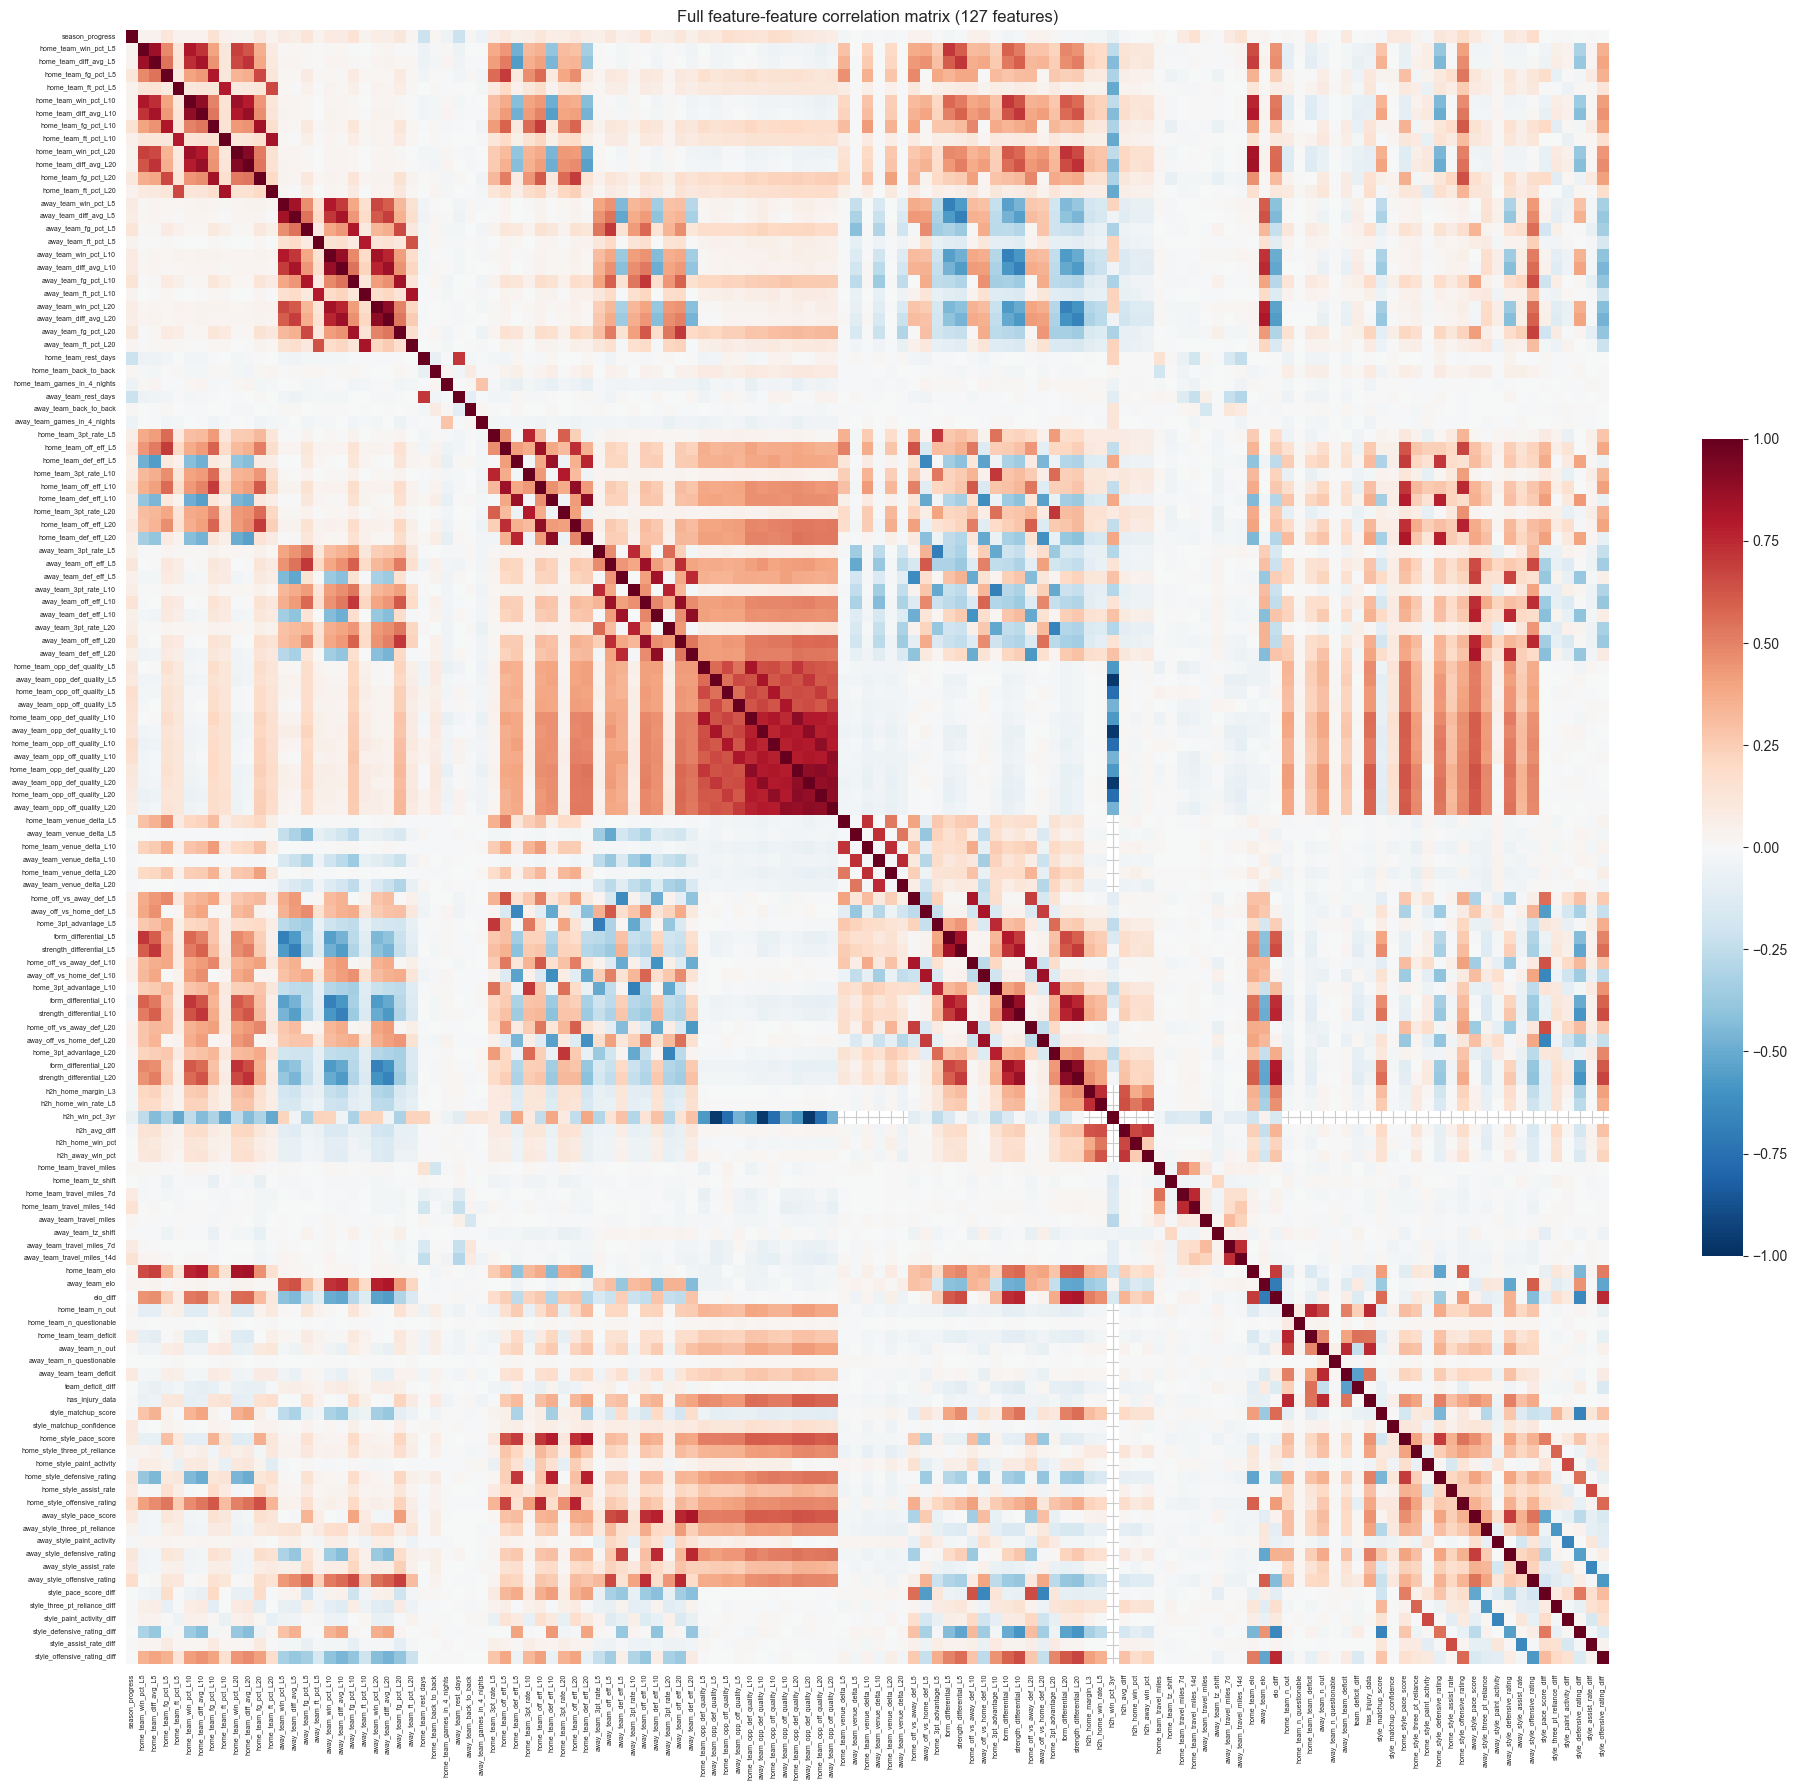

In [14]:
corr_full = df[feature_cols + ['POINT_DIFF','TOTAL_POINTS','HOME_TEAM_WINS']].corr()

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(corr_full.loc[feature_cols, feature_cols], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.5}, xticklabels=True, yticklabels=True)
ax.tick_params(axis='both', labelsize=5)
plt.title('Full feature-feature correlation matrix (127 features)')
plt.tight_layout()
plt.show()

In [15]:
# Highly correlated pairs (|r| > 0.9), excluding h2h_win_pct_3yr (known-broken, see Section 3)
fc = corr_full.loc[feature_cols, feature_cols]
cols = fc.columns
arr = fc.values
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = arr[i, j]
        if abs(r) > 0.9 and 'h2h_win_pct_3yr' not in (cols[i], cols[j]):
            pairs.append((cols[i], cols[j], r))
pairs.sort(key=lambda x: -abs(x[2]))
pd.DataFrame(pairs, columns=['feature_a', 'feature_b', 'corr'])

,feature_a,feature_b,corr
0,home_team_win_pct_L20,home_team_diff_avg_L20,0.914752
1,form_differential_L20,strength_differential_L20,0.901836


In [16]:
# Within-family redundancy: L5 vs L10 vs L20 for representative stats
for stat in ['home_team_off_eff', 'home_team_win_pct', 'home_team_diff_avg', 'home_team_3pt_rate']:
    cols3 = [f'{stat}_L{w}' for w in cfg.features.rolling_windows if f'{stat}_L{w}' in df.columns]
    print(stat)
    print(df[cols3].corr().round(3))
    print()

home_team_off_eff
                       home_team_off_eff_L5  home_team_off_eff_L10  \
home_team_off_eff_L5                  1.000                  0.854   
home_team_off_eff_L10                 0.854                  1.000   
home_team_off_eff_L20                 0.739                  0.886   

                       home_team_off_eff_L20  
home_team_off_eff_L5                   0.739  
home_team_off_eff_L10                  0.886  
home_team_off_eff_L20                  1.000  

home_team_win_pct
                       home_team_win_pct_L5  home_team_win_pct_L10  \
home_team_win_pct_L5                  1.000                  0.811   
home_team_win_pct_L10                 0.811                  1.000   
home_team_win_pct_L20                 0.684                  0.853   

                       home_team_win_pct_L20  
home_team_win_pct_L5                   0.684  
home_team_win_pct_L10                  0.853  
home_team_win_pct_L20                  1.000  

home_team_diff_avg
     

**Within-family redundancy is real but moderate, not extreme.** L5-vs-L20
correlations for the same underlying stat sit around 0.6-0.75, L10-vs-L20 around
0.85-0.89 — high but each window still carries distinguishable information (a
team's last-5-games form genuinely diverges from its last-20 more than noise
would predict). No single window looks safely droppable from this lens alone;
`home_team_win_pct_L20` / `home_team_diff_avg_L20` (r=0.915) and
`form_differential_L20` / `strength_differential_L20` (r=0.902) are the two pairs
that cross the 0.9 threshold — both are constructed the same way (win-rate vs.
margin-average of the same underlying game outcomes at the same window), so the
redundancy is expected, not a discovery.

In [ ]:
# The central raw-fingerprint-redesign question: is pace_score's importance just a
# correlated proxy for elo_diff, or something elo doesn't capture?
q_cols = ['home_style_pace_score', 'away_style_pace_score', 'style_pace_score_diff',
          'elo_diff', 'home_team_elo', 'away_team_elo',
          'home_style_offensive_rating', 'away_style_offensive_rating', 'style_offensive_rating_diff',
          'POINT_DIFF', 'TOTAL_POINTS', 'HOME_TEAM_WINS']
df[q_cols].corr().loc[['home_style_pace_score','away_style_pace_score','style_pace_score_diff',
                        'home_style_offensive_rating','away_style_offensive_rating','style_offensive_rating_diff'],
                       ['elo_diff','POINT_DIFF','TOTAL_POINTS','HOME_TEAM_WINS']]

**Answer: pace_score is NOT a redundant proxy for Elo — it's capturing something
genuinely orthogonal.** `home_style_pace_score`/`away_style_pace_score` correlate
essentially **zero** with `elo_diff` (-0.06 / +0.05) and with the spread/moneyline
labels (`POINT_DIFF` -0.04/+0.01, `HOME_TEAM_WINS` -0.04/-0.00), but correlate
**0.37-0.38 with `TOTAL_POINTS`** — pace_score (`PTS + OPP_PTS + TOV - FTA*0.44`,
per team) is fundamentally a combined-scoring-level proxy, and Elo (built from
margin-of-victory, not point totals) has no mechanism to capture that at all
(`elo_diff` vs `TOTAL_POINTS` correlates -0.003). This is exactly consistent with
the raw-fingerprint feature redesign's headline result: `pace_score` ranks #1/#2 in
CatBoost importance and drives the `total_mae` improvement, but doesn't move
`win_acc`/spread accuracy — it's adding *new* information the existing feature set
lacked, just information that's only useful for the over/under market, not the
spread/moneyline markets.

**Contrast with `style_offensive_rating_diff`** (rank #14 in that redesign's
importance table): this one correlates **0.75 with `elo_diff`** and 0.31 with
`POINT_DIFF` — much more redundant with information Elo already encodes. Two
features from that redesign that both got real importance arrived there via
opposite mechanisms: pace_score via genuinely new (total-points) information,
offensive_rating_diff via a correlated-but-not-identical restatement of team
quality Elo already tracks.

## Section 5: Feature-label correlation ranking

Every feature's correlation with `POINT_DIFF` (spread), `TOTAL_POINTS` (total), and
`HOME_TEAM_WINS` (moneyline) separately — a linear/rank lens, different from
CatBoost's tree-based split importance, and one that can reveal different things
per market.

In [18]:
for lbl in ['POINT_DIFF', 'TOTAL_POINTS', 'HOME_TEAM_WINS']:
    print(f"=== Top 15 |corr| with {lbl} ===")
    s = corr_full[lbl].drop(['POINT_DIFF','TOTAL_POINTS','HOME_TEAM_WINS']).abs().sort_values(ascending=False).head(15)
    for feat in s.index:
        print(f"  {feat:35s} {corr_full.loc[feat, lbl]:+.3f}")
    print()

=== Top 15 |corr| with POINT_DIFF ===
  elo_diff                            +0.386
  strength_differential_L20           +0.346
  strength_differential_L10           +0.326
  form_differential_L20               +0.319
  style_offensive_rating_diff         +0.311
  form_differential_L10               +0.295
  home_team_elo                       +0.292
  strength_differential_L5            +0.292
  h2h_win_pct_3yr                     +0.271
  style_defensive_rating_diff         -0.268
  home_team_diff_avg_L20              +0.262
  style_matchup_score                 +0.250
  form_differential_L5                +0.249
  home_team_diff_avg_L10              +0.249
  away_team_elo                       -0.249

=== Top 15 |corr| with TOTAL_POINTS ===
  home_style_pace_score               +0.377
  away_style_pace_score               +0.370
  home_team_def_eff_L20               +0.309
  away_team_def_eff_L20               +0.301
  home_team_def_eff_L10               +0.298
  away_team_off_eff_L

**Different markets are driven by different feature families, exactly as the
raw-fingerprint feature redesign implied.** `POINT_DIFF`/`HOME_TEAM_WINS`
(spread/moneyline) top lists are dominated by `elo_diff`, `strength_differential_L*`,
`form_differential_L*` — cumulative team-strength signals. `TOTAL_POINTS`'s top list
is a completely different set: `home/away_style_pace_score` (both ~0.37), then
rolling `off_eff`/`def_eff` at every window (all ~0.26-0.31) — pace/scoring-level
features, not team-strength differentials at all. `home_style_pace_score` doesn't
even crack the top 15 for `POINT_DIFF` or `HOME_TEAM_WINS`. `h2h_win_pct_3yr`
appears high in the `POINT_DIFF`/`HOME_TEAM_WINS` lists (+0.27, +0.25) — per
Section 3, this is **noise from the reindex bug** (n=36), not a real signal;
ignore it.

## Section 6: Era drift over time

Already established elsewhere in this project that pace/3PT rate shifted since
2016 (design doc references this era). Check whether it's visible directly in
these features.

In [19]:
era = df.groupby('season_year').agg(
    combined_scoring_level=('home_team_off_eff_L20', 'mean'),   # proxy for league pace/scoring level
    three_pt_attempt_rate=('home_style_three_pt_reliance', 'mean'),  # true 3PA/FGA rate (not FG3_PCT)
    home_win_rate=('HOME_TEAM_WINS', 'mean'),
    n_games=('GAME_ID', 'count'),
)
era

,combined_scoring_level,three_pt_attempt_rate,home_win_rate,n_games
season_year,,,,
2016,105.047613,0.309203,0.573123,506
2017,107.308462,0.325871,0.585746,1347
2018,108.442667,0.343079,0.599544,1316
2019,112.324546,0.367102,0.573796,1267
2020,112.906516,0.389150,0.524079,706
2021,112.042585,0.396581,0.546462,1625
2022,112.253930,0.397011,0.574850,1336
2023,115.911138,0.387953,0.564904,1248
2024,114.632483,0.402517,0.536938,1313


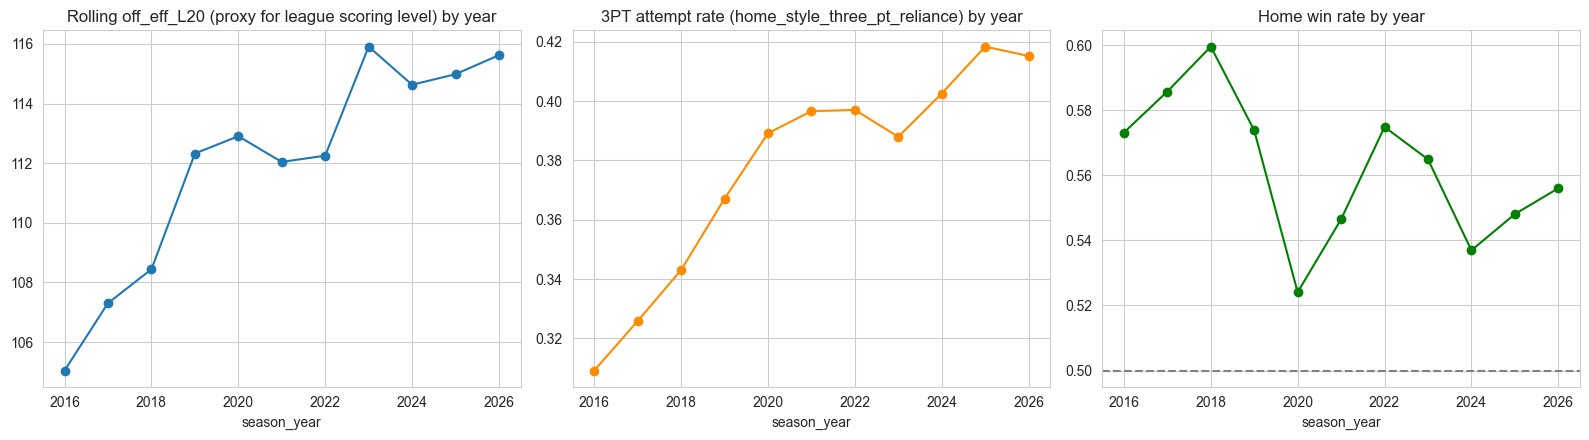

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
era['combined_scoring_level'].plot(ax=axes[0], marker='o')
axes[0].set_title('Rolling off_eff_L20 (proxy for league scoring level) by year')
era['three_pt_attempt_rate'].plot(ax=axes[1], marker='o', color='darkorange')
axes[1].set_title('3PT attempt rate (home_style_three_pt_reliance) by year')
era['home_win_rate'].plot(ax=axes[2], marker='o', color='green')
axes[2].axhline(0.5, color='gray', linestyle='--')
axes[2].set_title('Home win rate by year')
plt.tight_layout()
plt.show()

**Era drift confirmed directly in the feature values.** League scoring level
(`home_team_off_eff_L20`, a rolling points-scored proxy) rises from ~105 (2016)
to ~116 (2025-26), a real ~10% increase consistent with the well-documented
pace-and-space shift. 3PT attempt rate (`home_style_three_pt_reliance`, the true
3PA/FGA ratio — not `home_team_3pt_rate_L*`, which is `FG3_PCT`, make-rate, and
stays flat ~0.35-0.37 across eras since shooting *accuracy* hasn't trended the
way attempt *volume* has) climbs from 0.31 to ~0.42, a genuine +35% relative
increase. Home-court advantage (`home_win_rate`) shows no clear secular trend —
stays in a 0.53-0.58 band with no obvious drift, consistent with home advantage
being a relatively stable structural effect rather than an era-shifting one.

Note the naming trap this surfaces: `home_team_3pt_rate_L{window}` (rolling
`FG3_PCT`, i.e. 3PT *shooting percentage*) and `home_style_three_pt_reliance`
(3PA/FGA, i.e. 3PT *attempt rate*) sound like they'd move together but measure
different things — one is roughly flat over the study period, the other trends
sharply. Worth being deliberate about which one is meant when reasoning about
"the 3-point revolution" using this feature set.

## Section 7: Summary / next steps

See `docs/feature_eda_insights.md` for the concise bullet-point write-up (redundant
features, the pace_score/elo_diff question, the `h2h_win_pct_3yr` bug, and other
findings) intended for a human reader. Key results from this notebook, in one place:

1. **`h2h_win_pct_3yr` is broken** (index-reindex bug in
   `_compute_h2h_3year_win_pct`) — 99.7% NaN, and its ~36 surviving values are
   coincidental, not signal. Its apparent correlations with the labels are noise.
2. **`style_matchup_confidence` is ~constant** (99.3% of games at one value) —
   explains the KNN-score integration test's zero-importance finding structurally,
   not just empirically.
3. **`pace_score` is not redundant with `elo_diff`** (~0 correlation) — it's a
   genuinely new total-scoring-level signal Elo structurally cannot capture,
   which is why it helps `total_mae` but not `win_acc`/spread. By contrast
   `style_offensive_rating_diff` (also top-15 in that redesign) correlates 0.75 with
   `elo_diff` — much more redundant.
4. Known era-based coverage gaps (injury-report `pdf_era_start=2021-10-01`) show
   up exactly as documented; no comparable gap for A7 style-fingerprint features.
5. Era drift (scoring level, 3PT attempt rate) is directly visible in the feature
   values, consistent with prior project findings.
6. Rolling-window (L5/L10/L20) redundancy is real (0.6-0.89 correlation) but not
   extreme enough to recommend dropping any window outright.